# Logistic Regression implementation from scratch

### Imports

Loads the core libraries needed for the whole notebook — **pandas** for tabular data handling, **numpy** for the vectorized math behind the model, **matplotlib** for visualization, and **load_breast_cancer** from scikit-learn as a real-data source.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

### Loading Data

Loads the real Breast Cancer Wisconsin diagnostic dataset. Flips sklearn's default label encoding so **1 = malignant** (more intuitive for a diagnosis task), and selects two real features, **worst radius** and **worst concave points** as the model inputs.

In [13]:
data = load_breast_cancer(as_frame=True)
df = data.frame

# sklearn encodes 0=malignant, 1=benign — flip it so 1=malignant (has cancer),
# which is the more intuitive positive class for a diagnosis task
y_train = (1 - df["target"].values)
X_train = df[["worst radius", "worst concave points"]].values

m, n = X_train.shape
print(f"Number of examples: {m}, Number of features: {n}")
print(f"Class balance: {y_train.sum()} malignant, {m - y_train.sum()} benign")

Number of examples: 569, Number of features: 2
Class balance: 212 malignant, 357 benign


### Standardizing Features

Rescales both features to zero mean and unit standard deviation. Necessary here because **worst radius (~10–35)** and **worst concave points (~0–0.3)** sit on very different scales, which would otherwise make gradient descent converge unevenly across the two dimensions.

In [14]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_train_scaled = (X_train - X_mean) / X_std

### Visualization

Plots the two classes (benign vs. malignant) against each other on the two standardized features, to see visually whether they're separable before building any model.

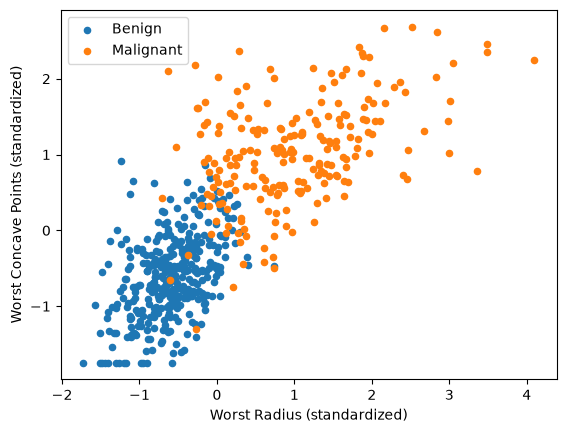

In [15]:
plt.scatter(X_train_scaled[y_train == 0, 0], X_train_scaled[y_train == 0, 1],
            color='tab:blue', label='Benign', s=20)
plt.scatter(X_train_scaled[y_train == 1, 0], X_train_scaled[y_train == 1, 1],
            color='tab:orange', label='Malignant', s=20)
plt.xlabel('Worst Radius (standardized)')
plt.ylabel('Worst Concave Points (standardized)')
plt.legend()
plt.show()

Shows real separation between the two classes: malignant tumors cluster toward higher standardized values of both features, though with some overlap.

### Sigmoid Function

Defines the function that converts any real-valued number into a 0–1 probability, turning the model's linear output into something interpretable as "probability of malignancy."


In [16]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

### Cost Function

Defines binary cross-entropy (log loss): the cost function appropriate for classification, penalizing confident wrong predictions far more heavily than uncertain ones.


In [17]:
def cost_function(X, y, w, b):
    cost_sum = 0

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        cost_sum += -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)

    return (1 / m) * cost_sum

### Gradient Function

Computes the gradient of the log-loss cost with respect to each weight and the bias, telling gradient descent which direction to adjust w and b to reduce classification error.

In [18]:
def gradient_function(X, y, w, b):
    grad_w = np.zeros(n)
    grad_b = 0

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        grad_b += (g - y[i])
        for j in range(n):
            grad_w[j] += (g - y[i]) * X[i, j]

    grad_b = (1 / m) * grad_b
    grad_w = (1 / m) * grad_w

    return grad_b, grad_w

### Gradient Descent

The core training loop — starts from w=0, b=0 and iteratively updates both using the gradient function, printing cost every 2000 steps to track convergence.

In [19]:
def gradient_descent(X, y, alpha, iterations):
    w = np.zeros(n)
    b = 0

    for i in range(iterations):
        grad_b, grad_w = gradient_function(X, y, w, b)

        w = w - alpha * grad_w
        b = b - alpha * grad_b

        if i % 2000 == 0:
            print(f"Iteration {i}: Cost {cost_function(X, y, w, b):.6f}")

    return w, b

### Predict Function

Converts the model's probability outputs into hard class predictions using a 0.5 threshold (≥0.5 → malignant, <0.5 → benign).

In [20]:
def predict(X, w, b):
    preds = np.zeros(m)

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        preds[i] = 1 if g >= 0.5 else 0

    return preds

### Training Model

Runs gradient descent for 10,000 iterations at a learning rate of 0.1, then uses **predict** to measure how well the trained model classifies the real training data.

In [21]:
learning_rate = 0.1
iterations = 10000

final_w, final_b = gradient_descent(X_train_scaled, y_train, learning_rate, iterations)

predictions = predict(X_train_scaled, final_w, final_b)
accuracy = np.mean(predictions == y_train) * 100
print(f"training accuracy: {accuracy:.2f}%")

Iteration 0: Cost 0.663373
Iteration 2000: Cost 0.126958
Iteration 4000: Cost 0.125136
Iteration 6000: Cost 0.124848
Iteration 8000: Cost 0.124790
training accuracy: 94.55%


Cost drops from 0.6634 to 0.1248 and flattens out: clean convergence, no divergence. Final parameters: **w = [4.6277, 2.9780], b = -0.9939**, achieving **94.55% training accuracy** on real cancer diagnosis labels.


### Visualizing the Decision Boundary

Converts the learned weights into a line **(y = mx + c)** and plots it over the scatter plot, shading each side by predicted class, to visually show where the model draws the line between malignant and benign.

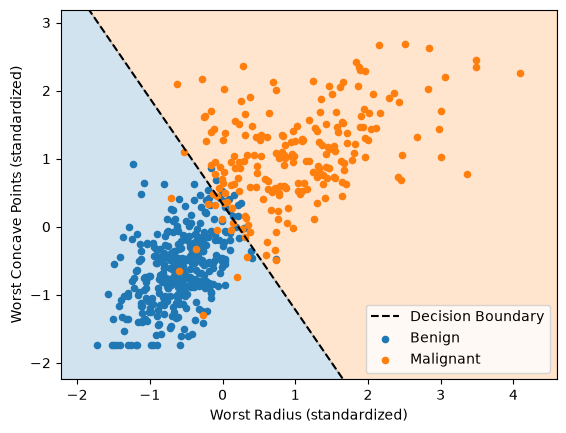

In [22]:
w0, w1 = final_w
m_line = -w0 / w1
c_line = -final_b / w1

xmin, xmax = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
ymin, ymax = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5
xd = np.array([xmin, xmax])
yd = m_line * xd + c_line

plt.plot(xd, yd, 'k', ls='--', label='Decision Boundary')
plt.fill_between(xd, yd, ymin, color='tab:blue', alpha=0.2)
plt.fill_between(xd, yd, ymax, color='tab:orange', alpha=0.2)

plt.scatter(X_train_scaled[y_train == 0, 0], X_train_scaled[y_train == 0, 1],
            color='tab:blue', label='Benign', s=20)
plt.scatter(X_train_scaled[y_train == 1, 0], X_train_scaled[y_train == 1, 1],
            color='tab:orange', label='Malignant', s=20)

plt.legend()
plt.xlabel('Worst Radius (standardized)')
plt.ylabel('Worst Concave Points (standardized)')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()

The dashed boundary line cuts through the region of class overlap, with **malignant** points concentrated in the **orange (upper-right) region** and **benign** points in the **blue (lower-left) region**, consistent with the 94.55% accuracy, meaning a small number of points fall on the "wrong" side.

### Sklearn Validation

Fits scikit-learn's **LogisticRegression** (with regularization essentially disabled via **C=1e6**, to match my unregularized from-scratch version) on the same standardized data, purely as an independent correctness check.


In [ ]:
from sklearn.linear_model import LogisticRegression

# using l1_ratio=0, C=large to match my from-scratch version, which has no regularization
sk_model = LogisticRegression(C=1e6, max_iter=10000)
sk_model.fit(X_train_scaled, y_train)

print(f"From scratch:  w={final_w}, b={final_b:.4f}")
print(f"sklearn:       w={sk_model.coef_[0]}, b={sk_model.intercept_[0]:.4f}")
print(f"sklearn accuracy: {sk_model.score(X_train_scaled, y_train)*100:.2f}%")

From scratch:  w=[4.62774106 2.97798985], b=-0.9939
sklearn:       w=[4.66694348 2.9795586 ], b=-0.9932
sklearn accuracy: 94.55%


Sklearn converges to nearly identical weights: **w = [4.667, 2.980], b = -0.993** vs. mine **w = [4.628, 2.978], b = -0.994**, which lands on the exact same **94.55% accuracy**. The small remaining difference in weights is expected: log loss doesn't have a closed-form solution like MSE does, so both my gradient descent and sklearn's optimizer are converging asymptotically toward the same optimum rather than solving it in one step.